## 1)Install/import libraries


In [1]:
###Install/import libraries
# ==========================================
# STEP 1: IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

## 2)Load the dataset

In [2]:
# ==========================================
# STEP 2: LOAD DATA
# ==========================================

file_path = "PJMW_MW_Hourly.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


## 3)First look at the data

In [3]:
# First 5 rows
df.head()

,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077
1,2002-12-31 02:00:00,4939
2,2002-12-31 03:00:00,4885
3,2002-12-31 04:00:00,4857
4,2002-12-31 05:00:00,4930


In [4]:
# Last 5 rows
df.tail()

,Datetime,PJMW_MW
143201,2018-01-01 20:00:00,8401
143202,2018-01-01 21:00:00,8373
143203,2018-01-01 22:00:00,8238
143204,2018-01-01 23:00:00,7958
143205,2018-01-02 00:00:00,7691


In [5]:
# Dataset dimensions
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 143206
Columns: 2


## 4)Understand columns

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  143206 non-null  datetime64[ns]
 1   PJMW_MW   143206 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.2 MB


In [7]:
##check column names:
print(df.columns)

Index(['Datetime', 'PJMW_MW'], dtype='object')


## 5)Statistical summary

In [8]:
df.describe()

,Datetime,PJMW_MW
count,143206,143206.000000
mean,2010-06-02 03:39:50.656816128,5602.375089
min,2002-04-01 01:00:00,487.000000
25%,2006-05-02 03:15:00,4907.000000
50%,2010-06-02 04:30:00,5530.000000
75%,2014-07-03 06:45:00,6252.000000
max,2018-08-03 00:00:00,9594.000000
std,NaN,979.142872


## 6)Check missing values

In [9]:
# ==========================================
# STEP 3: MISSING VALUES
# ==========================================

print(df.isnull().sum())

Datetime    0
PJMW_MW     0
dtype: int64


In [10]:
missing_percentage = df.isnull().mean() * 100

print(missing_percentage)

Datetime    0.0
PJMW_MW     0.0
dtype: float64


## 7)Check duplicate rows

In [11]:
print("Duplicate rows:",
      df.duplicated().sum())

Duplicate rows: 0


In [12]:
## Also check duplicate timestamps:
print("Duplicate timestamps:",
      df["Datetime"].duplicated().sum())

Duplicate timestamps: 4


In [13]:
duplicates = df[df["Datetime"].duplicated(keep=False)]

duplicates.sort_values("Datetime")

,Datetime,PJMW_MW
104424,2014-11-02 02:00:00,4613
104425,2014-11-02 02:00:00,4571
113208,2015-11-01 02:00:00,3927
113209,2015-11-01 02:00:00,3832
121848,2016-11-06 02:00:00,4114
121849,2016-11-06 02:00:00,4089
130656,2017-11-05 02:00:00,4042
130657,2017-11-05 02:00:00,3984


## 8)Convert Datetime correctly

In [14]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

In [15]:
## sort the data:
df = df.sort_values("Datetime").reset_index(drop=True)

In [16]:
## 9)Set Datetime as index
df = df.set_index("Datetime")

In [17]:
df.head()

,PJMW_MW
Datetime,
2002-04-01 01:00:00,4374
2002-04-01 02:00:00,4306
2002-04-01 03:00:00,4322
2002-04-01 04:00:00,4359
2002-04-01 05:00:00,4436


## 9)Check date range

In [18]:
print("Start date:", df.index.min())
print("End date:", df.index.max())

Start date: 2002-04-01 01:00:00
End date: 2018-08-03 00:00:00


## 10)Check whether observations are hourly

In [19]:
time_difference = df.index.to_series().diff()

print(time_difference.value_counts().head(10))

Datetime
0 days 01:00:00    143171
0 days 02:00:00        30
0 days 00:00:00         4
Name: count, dtype: int64


In [20]:
## check abnormal gaps:
abnormal_gaps = time_difference[
    time_difference != pd.Timedelta(hours=1)
]

print(abnormal_gaps)

Datetime
2002-04-01 01:00:00               NaT
2002-04-07 04:00:00   0 days 02:00:00
2002-10-27 03:00:00   0 days 02:00:00
2003-04-06 04:00:00   0 days 02:00:00
2003-10-26 03:00:00   0 days 02:00:00
2004-04-04 04:00:00   0 days 02:00:00
2004-10-31 03:00:00   0 days 02:00:00
2005-04-03 04:00:00   0 days 02:00:00
2005-10-30 03:00:00   0 days 02:00:00
2006-04-02 04:00:00   0 days 02:00:00
2006-10-29 03:00:00   0 days 02:00:00
2007-03-11 04:00:00   0 days 02:00:00
2007-11-04 03:00:00   0 days 02:00:00
2008-03-09 04:00:00   0 days 02:00:00
2008-11-02 03:00:00   0 days 02:00:00
2009-03-08 04:00:00   0 days 02:00:00
2009-11-01 03:00:00   0 days 02:00:00
2010-03-14 04:00:00   0 days 02:00:00
2010-11-07 03:00:00   0 days 02:00:00
2010-12-10 01:00:00   0 days 02:00:00
2011-03-13 04:00:00   0 days 02:00:00
2011-11-06 03:00:00   0 days 02:00:00
2012-03-11 04:00:00   0 days 02:00:00
2012-11-04 03:00:00   0 days 02:00:00
2013-03-10 04:00:00   0 days 02:00:00
2013-11-03 03:00:00   0 days 02:00:00
201

## 11)Basic time-series plot

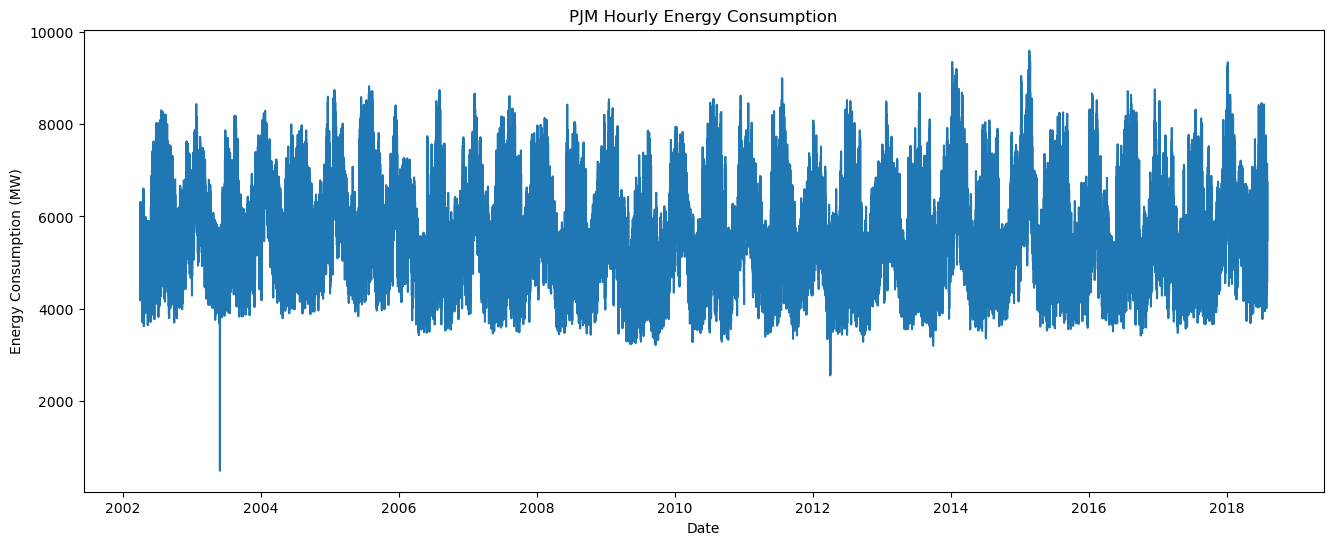

In [21]:
plt.figure(figsize=(16, 6))

plt.plot(df.index, df["PJMW_MW"])

plt.title("PJM Hourly Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (MW)")

plt.show()

## 12)Plot only one year

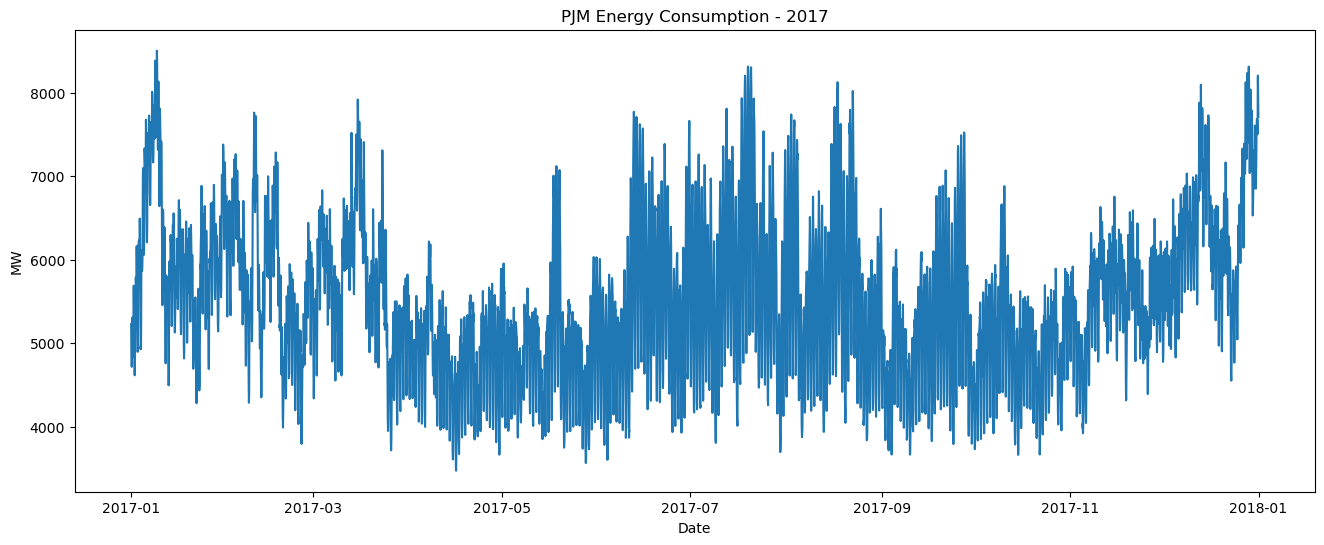

In [22]:
one_year = df.loc["2017"]

plt.figure(figsize=(16, 6))

plt.plot(one_year.index, one_year["PJMW_MW"])

plt.title("PJM Energy Consumption - 2017")
plt.xlabel("Date")
plt.ylabel("MW")

plt.show()

## 13)Create time features

In [23]:
# ==========================================
# STEP 4: CREATE TIME FEATURES
# ==========================================

df["Year"] = df.index.year
df["Month"] = df.index.month
df["Day"] = df.index.day
df["Hour"] = df.index.hour
df["DayOfWeek"] = df.index.dayofweek
df["DayName"] = df.index.day_name()
df["MonthName"] = df.index.month_name()
df["Quarter"] = df.index.quarter

## 14)Hourly consumption pattern

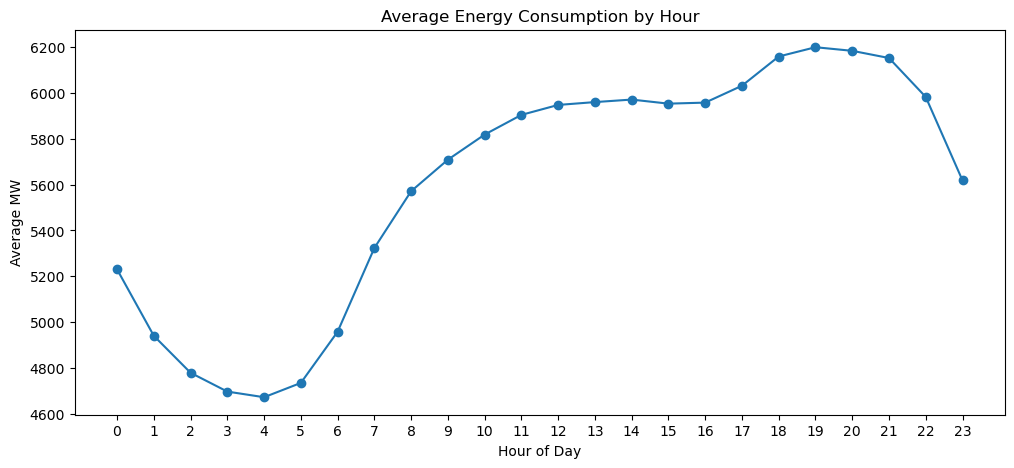

In [24]:
hourly_pattern = df.groupby("Hour")["PJMW_MW"].mean()

plt.figure(figsize=(12, 5))

plt.plot(hourly_pattern.index,
         hourly_pattern.values,
         marker="o")

plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average MW")
plt.xticks(range(24))

plt.show()

## 15)Day-of-week analysis


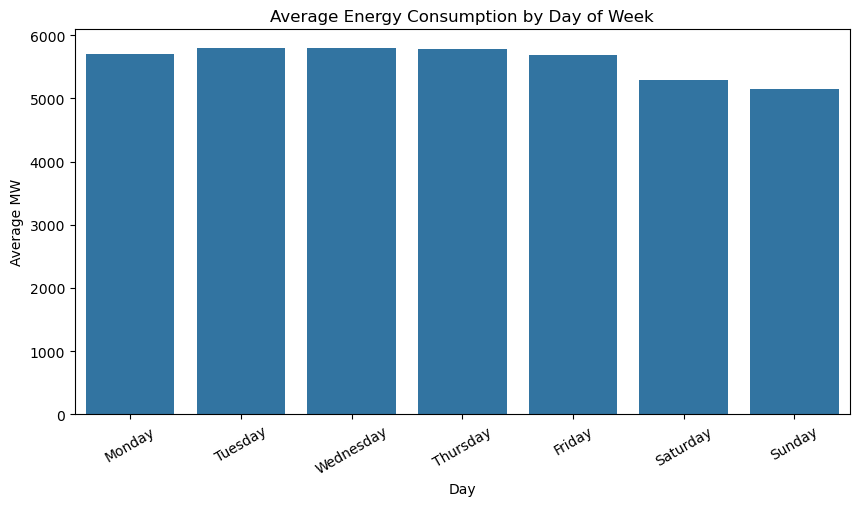

In [25]:
weekday_pattern = df.groupby("DayName")["PJMW_MW"].mean()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_pattern = weekday_pattern.reindex(weekday_order)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=weekday_pattern.index,
    y=weekday_pattern.values
)

plt.title("Average Energy Consumption by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average MW")

plt.xticks(rotation=30)

plt.show()

### 16)HOLIDAY ANALYSIS

In [26]:
# ==========================================
# HOLIDAY ANALYSIS
# ==========================================

from pandas.tseries.holiday import USFederalHolidayCalendar

# Create US federal holiday calendar
calendar = USFederalHolidayCalendar()

# Get holidays between dataset start and end dates
holidays = calendar.holidays(
    start=df.index.min(),
    end=df.index.max()
)

# Create Holiday column
df["IsHoliday"] = df.index.normalize().isin(holidays)

print("Holiday observations:", df["IsHoliday"].sum())
print("Non-holiday observations:", (~df["IsHoliday"]).sum())


Holiday observations: 3888
Non-holiday observations: 139318


### 17)HOLIDAY VS NON-HOLIDAY CONSUMPTION

Non-Holiday    5604.746436
Holiday        5517.403035
Name: PJMW_MW, dtype: float64


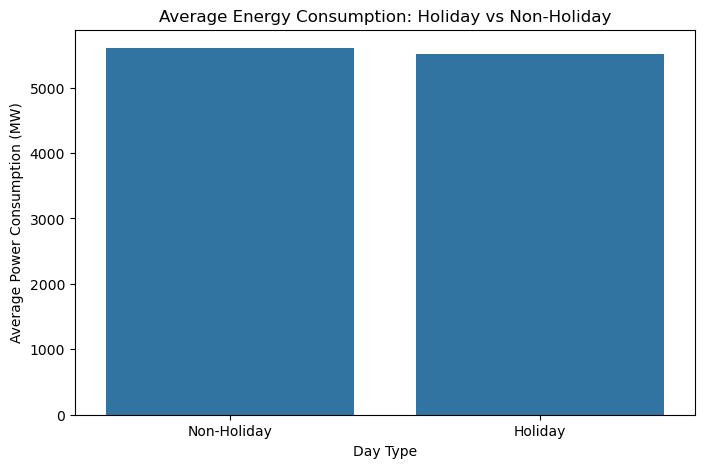

In [27]:
# ==========================================
# HOLIDAY VS NON-HOLIDAY CONSUMPTION
# ==========================================

holiday_pattern = (
    df.groupby("IsHoliday")["PJMW_MW"]
    .mean()
)

holiday_pattern.index = [
    "Non-Holiday" if x == False else "Holiday"
    for x in holiday_pattern.index
]

print(holiday_pattern)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=holiday_pattern.index,
    y=holiday_pattern.values
)

plt.title("Average Energy Consumption: Holiday vs Non-Holiday")
plt.xlabel("Day Type")
plt.ylabel("Average Power Consumption (MW)")

plt.show()

### 18)HOLIDAY × HOUR ANALYSIS

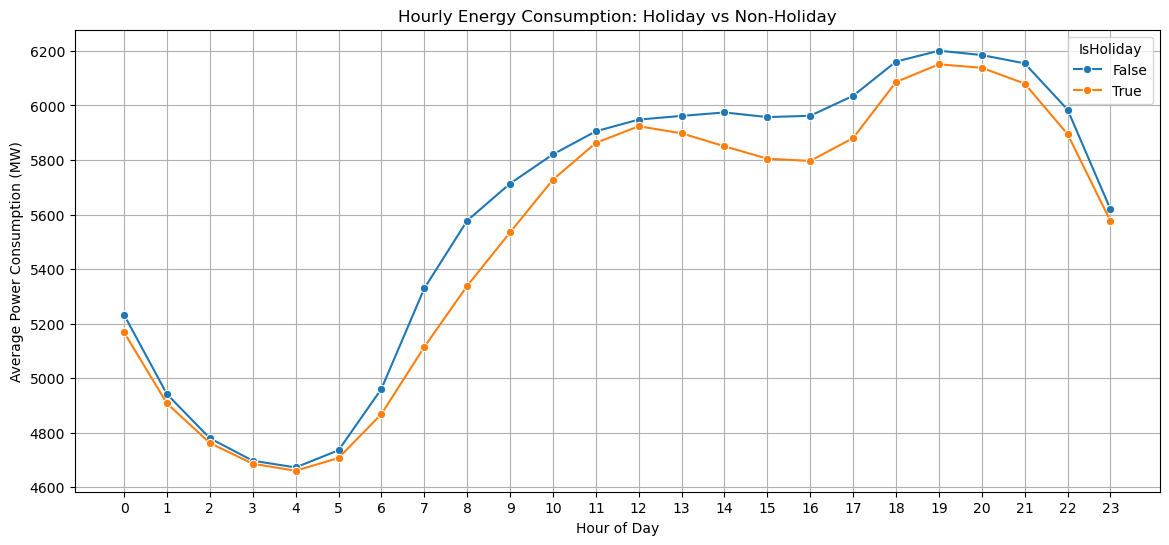

In [28]:
# ==========================================
# HOLIDAY × HOUR ANALYSIS
# ==========================================

holiday_hour = (
    df.groupby(
        ["IsHoliday", "Hour"]
    )["PJMW_MW"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=holiday_hour,
    x="Hour",
    y="PJMW_MW",
    hue="IsHoliday",
    marker="o"
)

plt.title("Hourly Energy Consumption: Holiday vs Non-Holiday")
plt.xlabel("Hour of Day")
plt.ylabel("Average Power Consumption (MW)")

plt.xticks(range(24))

plt.grid(True)

plt.show()

### 19)Monthly consumption

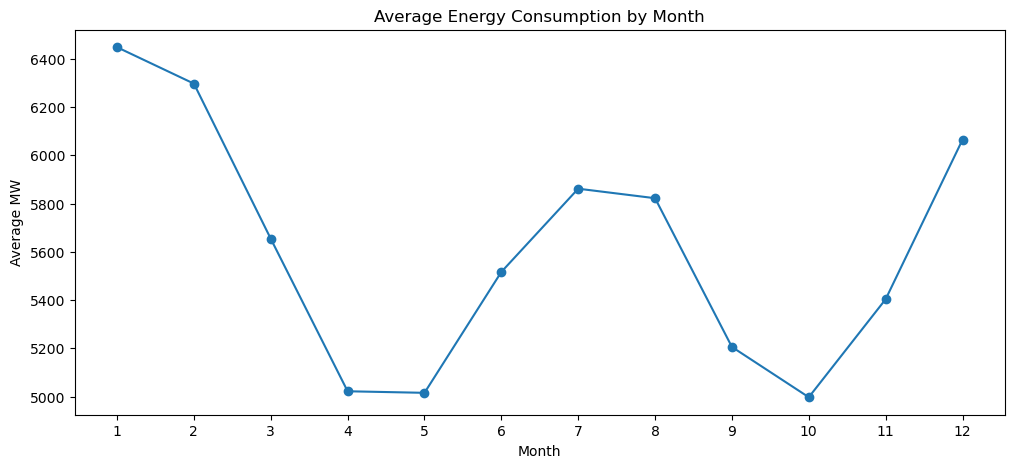

In [29]:
monthly_pattern = df.groupby("Month")["PJMW_MW"].mean()

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_pattern.index,
    monthly_pattern.values,
    marker="o"
)

plt.title("Average Energy Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average MW")

plt.xticks(range(1, 13))

plt.show()

## 20)Yearly trend

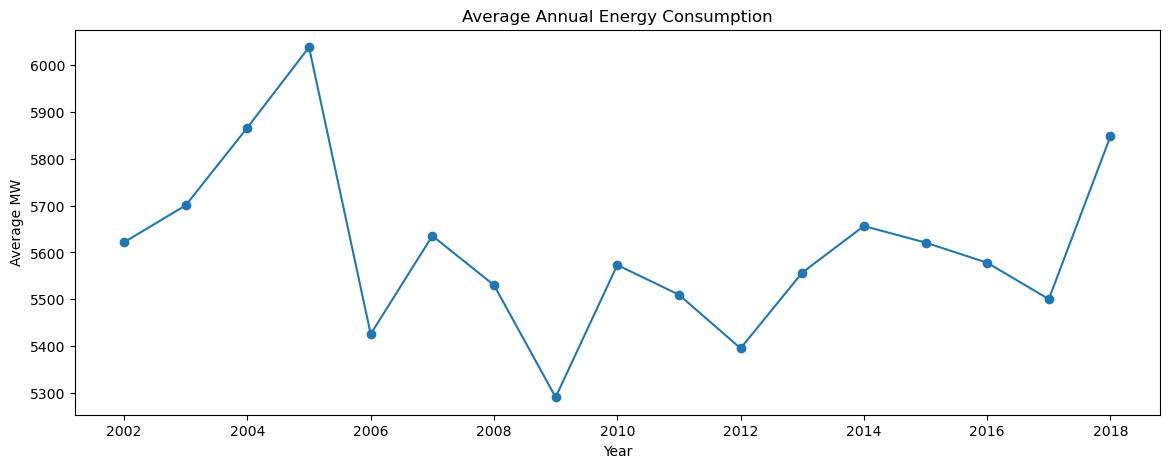

In [30]:
yearly_pattern = df.groupby("Year")["PJMW_MW"].mean()

plt.figure(figsize=(14, 5))

plt.plot(
    yearly_pattern.index,
    yearly_pattern.values,
    marker="o"
)

plt.title("Average Annual Energy Consumption")
plt.xlabel("Year")
plt.ylabel("Average MW")

plt.show()

## 21)Summer vs Winter

In [31]:
## create seasons:
def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Spring"

    elif month in [6, 7, 8]:
        return "Summer"

    else:
        return "Autumn"


df["Season"] = df["Month"].apply(get_season)

In [32]:
season_pattern = df.groupby("Season")["PJMW_MW"].mean()

print(season_pattern)

Season
Autumn    5200.143147
Spring    5224.394790
Summer    5734.206129
Winter    6268.813851
Name: PJMW_MW, dtype: float64


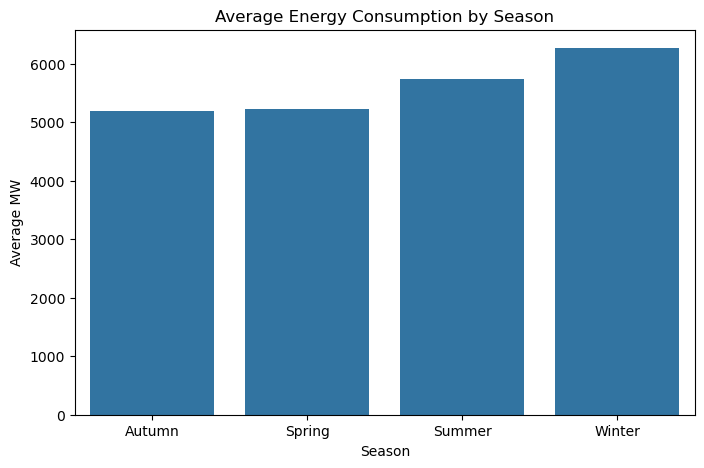

In [33]:
##plot:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_pattern.index,
    y=season_pattern.values
)

plt.title("Average Energy Consumption by Season")
plt.xlabel("Season")
plt.ylabel("Average MW")

plt.show()

## 22)Hourly pattern by season

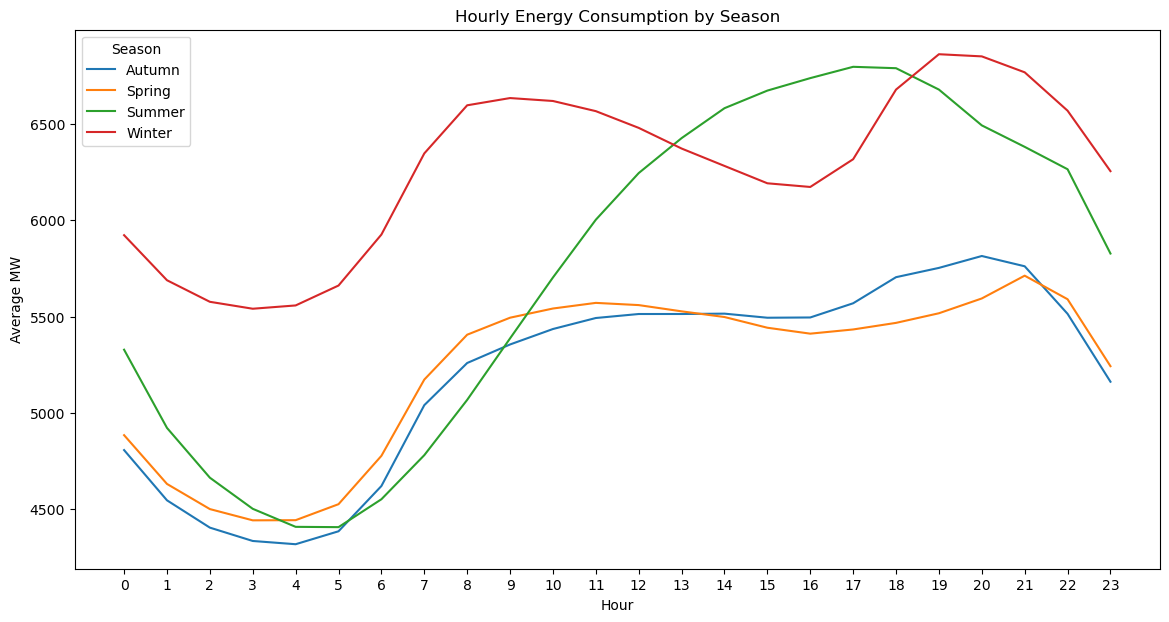

In [34]:
##Hourly pattern by season
season_hour = df.groupby(
    ["Season", "Hour"]
)["PJMW_MW"].mean().reset_index()

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=season_hour,
    x="Hour",
    y="PJMW_MW",
    hue="Season"
)

plt.title("Hourly Energy Consumption by Season")
plt.xlabel("Hour")
plt.ylabel("Average MW")

plt.xticks(range(24))

plt.show()

## 23)Distribution of energy consumption

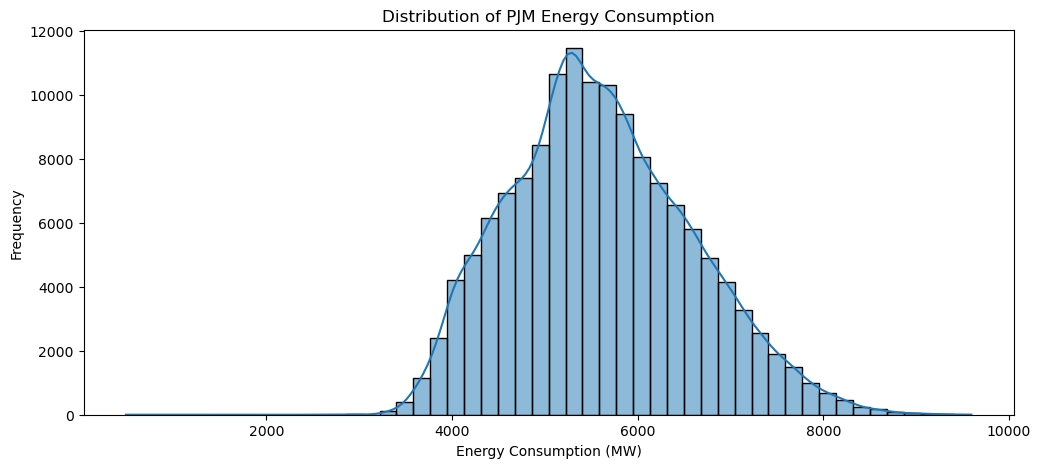

In [35]:
## Distribution of energy consumption
plt.figure(figsize=(12, 5))

sns.histplot(
    df["PJMW_MW"],
    bins=50,
    kde=True
)

plt.title("Distribution of PJM Energy Consumption")
plt.xlabel("Energy Consumption (MW)")
plt.ylabel("Frequency")

plt.show()

## 24)Boxplot

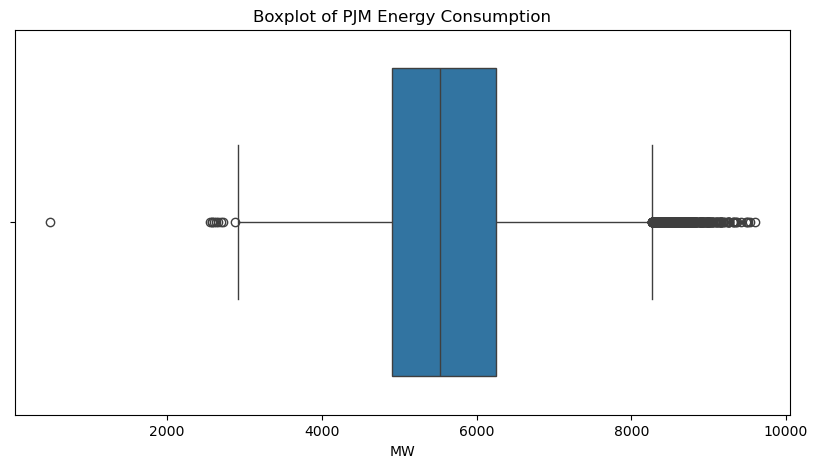

In [36]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df["PJMW_MW"]
)

plt.title("Boxplot of PJM Energy Consumption")
plt.xlabel("MW")

plt.show()

In [37]:
Q1 = df["PJMW_MW"].quantile(0.25)
Q3 = df["PJMW_MW"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["PJMW_MW"] < lower_limit) |
    (df["PJMW_MW"] > upper_limit)
]

print("Number of potential outliers:", len(outliers))

Number of potential outliers: 703


## 25)Rolling mean — important for trend

In [38]:
df["Rolling_24H"] = (
    df["PJMW_MW"]
    .rolling(window=24)
    .mean()
)

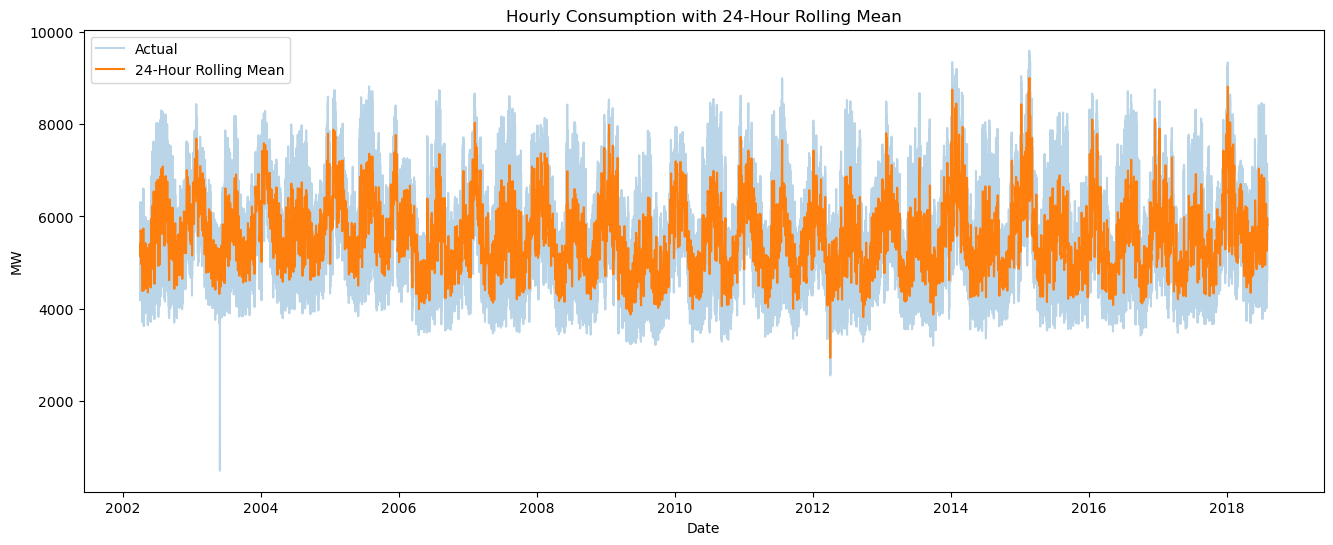

In [39]:
##plot:
plt.figure(figsize=(16, 6))

plt.plot(
    df.index,
    df["PJMW_MW"],
    alpha=0.3,
    label="Actual"
)

plt.plot(
    df.index,
    df["Rolling_24H"],
    label="24-Hour Rolling Mean"
)

plt.title("Hourly Consumption with 24-Hour Rolling Mean")
plt.xlabel("Date")
plt.ylabel("MW")

plt.legend()

plt.show()


## 26)Weekly rolling average

In [40]:
df["Rolling_168H"] = (
    df["PJMW_MW"]
    .rolling(window=168)
    .mean()
)

## 27)Time-series decomposition

In [41]:
daily = df["PJMW_MW"].resample("D").mean()

In [42]:
decomposition = seasonal_decompose(
    daily,
    model="additive",
    period=7
)

<Figure size 1400x1000 with 0 Axes>

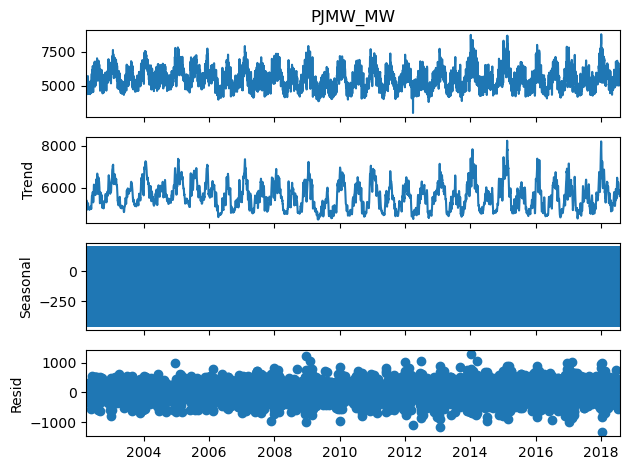

In [43]:
##plot:
plt.figure(figsize=(14, 10))

decomposition.plot()

plt.show()


## 28)Autocorrelation

<Figure size 1400x500 with 0 Axes>

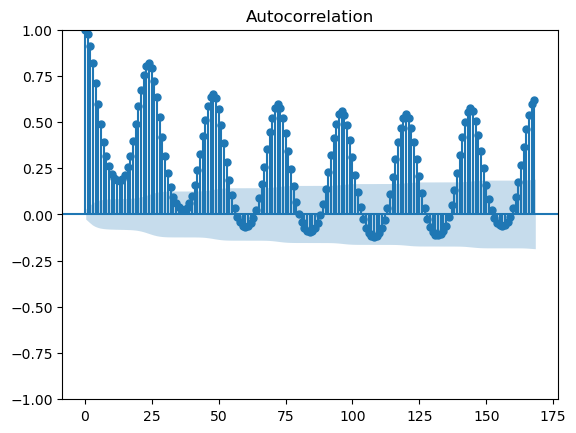

In [44]:
plt.figure(figsize=(14, 5))

plot_acf(
    df["PJMW_MW"].dropna().iloc[-5000:],
    lags=168
)

plt.show()

## 29)PACF

<Figure size 1400x500 with 0 Axes>

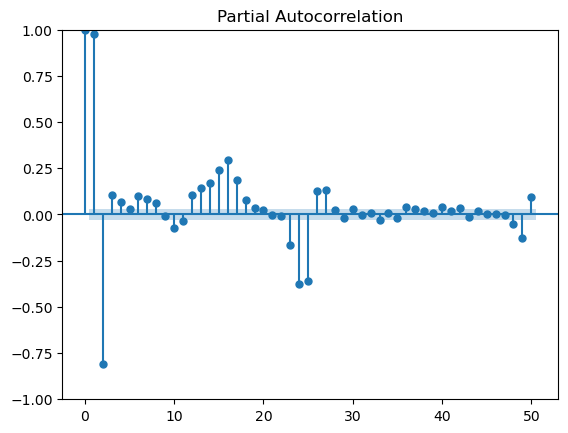

In [45]:
plt.figure(figsize=(14, 5))

plot_pacf(
    df["PJMW_MW"].dropna().iloc[-5000:],
    lags=50,
    method="ywm"
)

plt.show()

## 30)Visual stationarity check

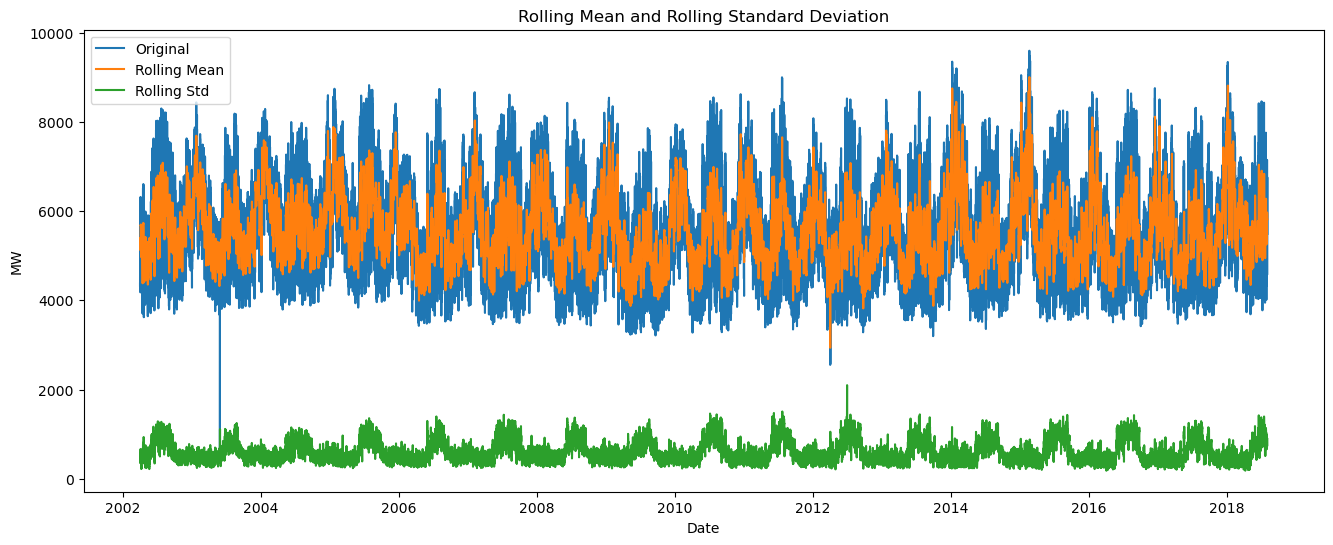

In [46]:
series = df["PJMW_MW"]

rolling_mean = series.rolling(24).mean()
rolling_std = series.rolling(24).std()

plt.figure(figsize=(16, 6))

plt.plot(series, label="Original")

plt.plot(
    rolling_mean,
    label="Rolling Mean"
)

plt.plot(
    rolling_std,
    label="Rolling Std"
)

plt.title("Rolling Mean and Rolling Standard Deviation")

plt.xlabel("Date")
plt.ylabel("MW")

plt.legend()

plt.show()

## 31)ADF Test

In [47]:
def adf_test(series, name="Series"):

    result = adfuller(
        series.dropna(),
        maxlag=24,
        autolag=None
    )

    print("====================================")
    print("ADF TEST:", name)
    print("====================================")

    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

    print("Critical Values:")

    for key, value in result[4].items():
        print(f"{key}: {value}")

    if result[1] < 0.05:
        print("\nConclusion: Reject H0")
        print("The series is stationary according to ADF.")

    else:
        print("\nConclusion: Fail to reject H0")
        print("The series is non-stationary according to ADF.")

In [48]:
adf_test(df["PJMW_MW"], "Original PJM Series")

ADF TEST: Original PJM Series
ADF Statistic: -39.738810464202096
p-value: 0.0
Critical Values:
1%: -3.4303956723813918
5%: -2.861560186544115
10%: -2.5667807445793684

Conclusion: Reject H0
The series is stationary according to ADF.


## ADF hypothesis

## 32)KPSS Test

In [49]:
def kpss_test(series, name="Series"):

    result = kpss(
        series.dropna(),
        regression="c",
        nlags=24
    )

    print("====================================")
    print("KPSS TEST:", name)
    print("====================================")

    print("KPSS Statistic:", result[0])
    print("p-value:", result[1])

    print("Critical Values:")

    for key, value in result[3].items():
        print(f"{key}: {value}")

    if result[1] < 0.05:
        print("\nConclusion: Reject H0")
        print("The series is non-stationary according to KPSS.")

    else:
        print("\nConclusion: Fail to reject H0")
        print("The series is stationary according to KPSS.")

In [50]:
kpss_test(df["PJMW_MW"], "Original PJM Series")

KPSS TEST: Original PJM Series
KPSS Statistic: 5.998176714442993
p-value: 0.01
Critical Values:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739

Conclusion: Reject H0
The series is non-stationary according to KPSS.


C:\Users\Sandhya\AppData\Local\Temp\ipykernel_30444\3843976068.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(


## 33)First differencing

In [51]:
df["Diff_1"] = df["PJMW_MW"].diff()

In [52]:
adf_test(
    df["Diff_1"],
    "First Differenced Series"
)

ADF TEST: First Differenced Series
ADF Statistic: -58.7061643215915
p-value: 0.0
Critical Values:
1%: -3.4303956727003833
5%: -2.8615601866851037
10%: -2.5667807446544115

Conclusion: Reject H0
The series is stationary according to ADF.


In [53]:
kpss_test(
    df["Diff_1"],
    "First Differenced Series"
)

KPSS TEST: First Differenced Series
KPSS Statistic: 0.0009335441503682172
p-value: 0.1
Critical Values:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739

Conclusion: Fail to reject H0
The series is stationary according to KPSS.


C:\Users\Sandhya\AppData\Local\Temp\ipykernel_30444\3843976068.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(


## 34)Plot differenced series

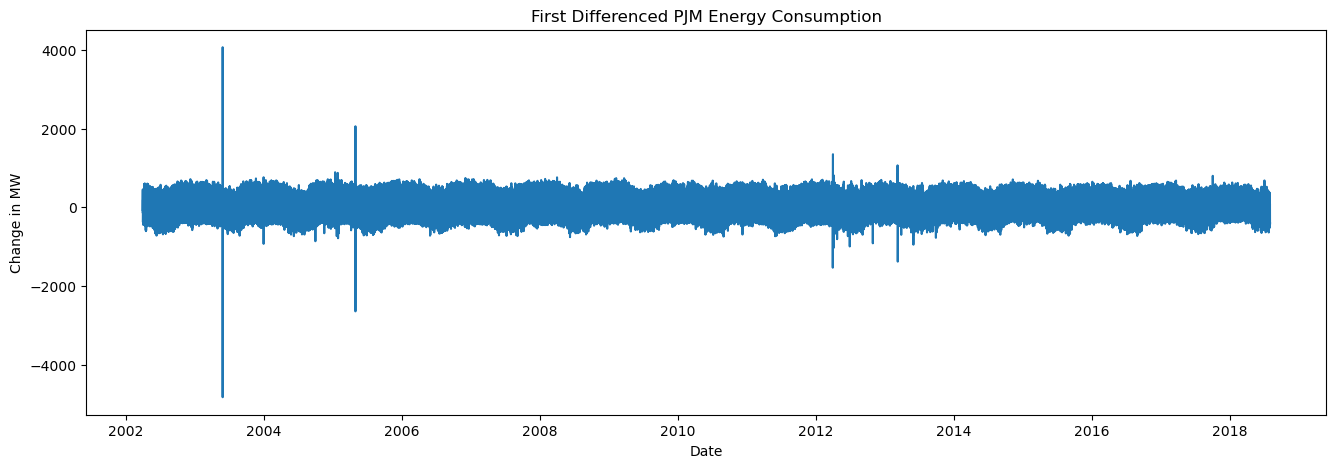

In [54]:
plt.figure(figsize=(16, 5))

plt.plot(df["Diff_1"])

plt.title("First Differenced PJM Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Change in MW")

plt.show()

## 35)Seasonal differencing

In [55]:
df["Diff_24"] = (
    df["PJMW_MW"] -
    df["PJMW_MW"].shift(24)
)

In [56]:
adf_test(
    df["Diff_24"],
    "24-Hour Seasonal Difference"
)

ADF TEST: 24-Hour Seasonal Difference
ADF Statistic: -52.13585900566564
p-value: 0.0
Critical Values:
1%: -3.4303956800384174
5%: -2.861560189928386
10%: -2.5667807463806995

Conclusion: Reject H0
The series is stationary according to ADF.


In [57]:
kpss_test(
    df["Diff_24"],
    "24-Hour Seasonal Difference"
)

KPSS TEST: 24-Hour Seasonal Difference
KPSS Statistic: 0.0006214848977236859
p-value: 0.1
Critical Values:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739

Conclusion: Fail to reject H0
The series is stationary according to KPSS.


C:\Users\Sandhya\AppData\Local\Temp\ipykernel_30444\3843976068.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(


## 36)Weekly seasonal differencing

In [58]:
df["Diff_168"] = (
    df["PJMW_MW"] -
    df["PJMW_MW"].shift(168)
)

In [59]:
adf_test(
    df["Diff_168"],
    "168-Hour Seasonal Difference"
)

ADF TEST: 168-Hour Seasonal Difference
ADF Statistic: -39.13657962313722
p-value: 0.0
Critical Values:
1%: -3.430395726034541
5%: -2.8615602102578626
10%: -2.5667807572013843

Conclusion: Reject H0
The series is stationary according to ADF.


In [60]:
kpss_test(
    df["Diff_168"],
    "168-Hour Seasonal Difference"
)

KPSS TEST: 168-Hour Seasonal Difference
KPSS Statistic: 0.008629208381645482
p-value: 0.1
Critical Values:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739

Conclusion: Fail to reject H0
The series is stationary according to KPSS.


C:\Users\Sandhya\AppData\Local\Temp\ipykernel_30444\3843976068.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(


## 37)Stationarity summary table

In [61]:
stationarity_summary = []

series_list = {
    "Original": df["PJMW_MW"],
    "First Difference": df["PJMW_MW"].diff(),
    "24-Hour Difference": df["PJMW_MW"].diff(24),
    "168-Hour Difference": df["PJMW_MW"].diff(168)
}

for name, series in series_list.items():

    series = series.dropna()

    adf_result = adfuller(
        series,
        maxlag=24,
        autolag=None
    )

    kpss_result = kpss(
        series,
        regression="c",
        nlags=24
    )

    stationarity_summary.append({
        "Series": name,
        "ADF p-value": adf_result[1],
        "KPSS p-value": kpss_result[1]
    })

stationarity_df = pd.DataFrame(stationarity_summary)

stationarity_df

C:\Users\Sandhya\AppData\Local\Temp\ipykernel_30444\3103052631.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(
C:\Users\Sandhya\AppData\Local\Temp\ipykernel_30444\3103052631.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(
C:\Users\Sandhya\AppData\Local\Temp\ipykernel_30444\3103052631.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(
C:\Users\Sandhya\AppData\Local\Temp\ipykernel_30444\3103052631.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-val

,Series,ADF p-value,KPSS p-value
0,Original,0.0,0.01
1,First Difference,0.0,0.10
2,24-Hour Difference,0.0,0.10
3,168-Hour Difference,0.0,0.10


## 38)Correlation heatmap

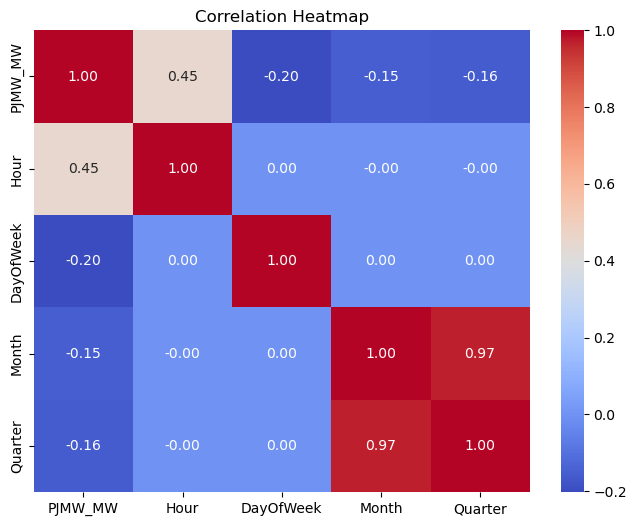

In [62]:
correlation_columns = [
    "PJMW_MW",
    "Hour",
    "DayOfWeek",
    "Month",
    "Quarter"
]

corr = df[correlation_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## 39)Hour × Day-of-week heatmap

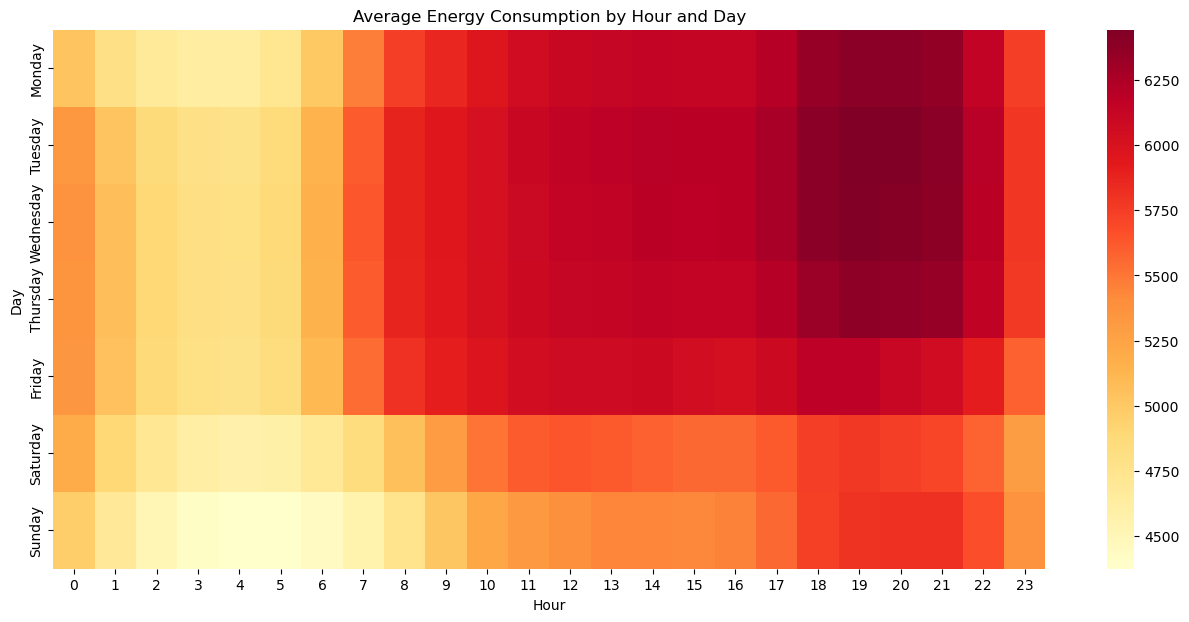

In [63]:
hour_day = df.pivot_table(
    values="PJMW_MW",
    index="DayName",
    columns="Hour",
    aggfunc="mean"
)

hour_day = hour_day.reindex([
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
])

plt.figure(figsize=(16, 7))

sns.heatmap(
    hour_day,
    cmap="YlOrRd"
)

plt.title("Average Energy Consumption by Hour and Day")
plt.xlabel("Hour")
plt.ylabel("Day")

plt.show()

## 40)Monthly × hour heatmap

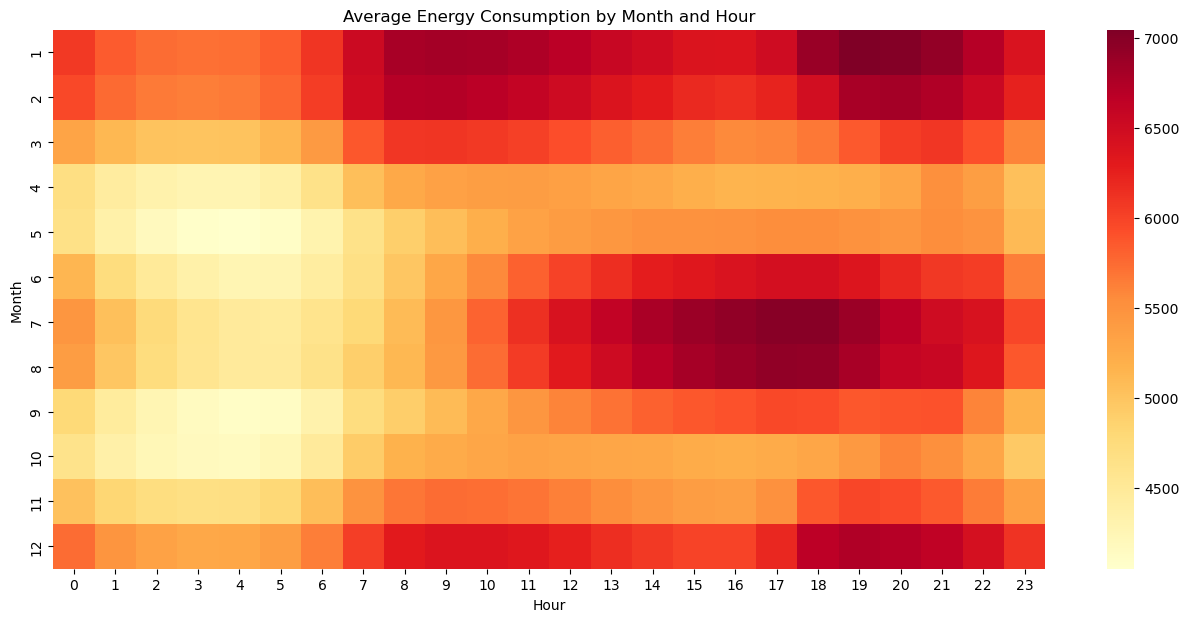

In [64]:
month_hour = df.pivot_table(
    values="PJMW_MW",
    index="Month",
    columns="Hour",
    aggfunc="mean"
)

plt.figure(figsize=(16, 7))

sns.heatmap(
    month_hour,
    cmap="YlOrRd"
)

plt.title("Average Energy Consumption by Month and Hour")
plt.xlabel("Hour")
plt.ylabel("Month")

plt.show()

In [65]:
eda_df = df.copy()

print(eda_df.head())

                     PJMW_MW  Year  Month  Day  Hour  DayOfWeek DayName  \
Datetime                                                                  
2002-04-01 01:00:00     4374  2002      4    1     1          0  Monday   
2002-04-01 02:00:00     4306  2002      4    1     2          0  Monday   
2002-04-01 03:00:00     4322  2002      4    1     3          0  Monday   
2002-04-01 04:00:00     4359  2002      4    1     4          0  Monday   
2002-04-01 05:00:00     4436  2002      4    1     5          0  Monday   

                    MonthName  Quarter  IsHoliday  Season  Rolling_24H  \
Datetime                                                                 
2002-04-01 01:00:00     April        2      False  Spring          NaN   
2002-04-01 02:00:00     April        2      False  Spring          NaN   
2002-04-01 03:00:00     April        2      False  Spring          NaN   
2002-04-01 04:00:00     April        2      False  Spring          NaN   
2002-04-01 05:00:00     April 

In [66]:
eda_df["Lag_1"] = eda_df["PJMW_MW"].shift(1)
eda_df["Lag_24"] = eda_df["PJMW_MW"].shift(24)
eda_df["Lag_168"] = eda_df["PJMW_MW"].shift(168)

eda_df["Rolling_Mean_24"] = (
    eda_df["PJMW_MW"]
    .shift(1)
    .rolling(24)
    .mean()
)

## MODEL BUILDING & MODEL EVALUATION

In [67]:
model_df = df[['PJMW_MW']].copy()

model_df = model_df[
    ~model_df.index.duplicated(keep='first')
]

full_index = pd.date_range(
    start=model_df.index.min(),
    end=model_df.index.max(),
    freq='h'
)

model_df = model_df.reindex(full_index)

model_df['PJMW_MW'] = model_df['PJMW_MW'].interpolate(
    method='time'
)

model_df.index.name = 'Datetime'

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

## Train and test data

In [69]:
# ==========================================
# TRAIN - TEST SPLIT
# LAST 1 YEAR AS TEST DATA
# ==========================================

# Last date available in the dataset
last_date = model_df.index.max()

# One year before the last date
test_start = last_date - pd.DateOffset(years=1)

# Training data = everything before last 1 year
train = model_df.loc[
    model_df.index < test_start
].copy()

# Test data = last 1 year
test = model_df.loc[
    model_df.index >= test_start
].copy()

print("Training shape:", train.shape)
print("Testing shape :", test.shape)

print("\nTraining period:")
print(train.index.min())
print(train.index.max())

print("\nTesting period:")
print(test.index.min())
print(test.index.max())

print("\nTest period duration:")
print(test.index.max() - test.index.min())

Training shape: (134471, 1)
Testing shape : (8761, 1)

Training period:
2002-04-01 01:00:00
2017-08-02 23:00:00

Testing period:
2017-08-03 00:00:00
2018-08-03 00:00:00

Test period duration:
365 days 00:00:00


## Separate target

In [70]:
y_train = train['PJMW_MW']
y_test = test['PJMW_MW']

print("Training observations:", len(y_train))
print("Testing observations :", len(y_test))

Training observations: 134471
Testing observations : 8761


## MODEL 1 — NAIVE BASELINE

#### This is only a benchmark.

#### Because your data is hourly, use the same hour from the previous day.


In [71]:
# Previous-day seasonal naive forecast
naive_pred = model_df['PJMW_MW'].shift(24)

naive_pred = naive_pred.loc[test.index]

print(naive_pred.head())

Datetime
2017-08-03 00:00:00    5536.0
2017-08-03 01:00:00    5207.0
2017-08-03 02:00:00    4871.0
2017-08-03 03:00:00    4692.0
2017-08-03 04:00:00    4614.0
Freq: h, Name: PJMW_MW, dtype: float64


## MODEL 2 — ARIMA

In [72]:
# Use last 60 days of training data
arima_train = y_train.iloc[-24 * 60:]

print("ARIMA training size:", len(arima_train))

ARIMA training size: 1440


## Fit ARIMA

In [73]:
arima_model = ARIMA(
    arima_train,
    order=(1, 1, 1)
)

arima_result = arima_model.fit()

arima_pred = arima_result.forecast(
    steps=len(y_test)
)

arima_pred.index = y_test.index

print("ARIMA completed.")

ARIMA completed.


## MODEL 3 — SARIMA

In [74]:
sarima_model = SARIMAX(
    arima_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(
    disp=False
)

sarima_pred = sarima_result.forecast(
    steps=len(y_test)
)

sarima_pred.index = y_test.index

print("SARIMA completed.")

SARIMA completed.


## MODEL 4 — RANDOM FOREST

In [75]:
ml_df = model_df.copy()

# Lag features
ml_df['Lag_1'] = ml_df['PJMW_MW'].shift(1)
ml_df['Lag_2'] = ml_df['PJMW_MW'].shift(2)
ml_df['Lag_3'] = ml_df['PJMW_MW'].shift(3)

# Daily lags
ml_df['Lag_24'] = ml_df['PJMW_MW'].shift(24)
ml_df['Lag_48'] = ml_df['PJMW_MW'].shift(48)

# Weekly lag
ml_df['Lag_168'] = ml_df['PJMW_MW'].shift(168)

# Rolling features
ml_df['Rolling_Mean_24'] = (
    ml_df['PJMW_MW']
    .shift(1)
    .rolling(24)
    .mean()
)

ml_df['Rolling_Mean_168'] = (
    ml_df['PJMW_MW']
    .shift(1)
    .rolling(168)
    .mean()
)

# Calendar features
ml_df['Hour'] = ml_df.index.hour
ml_df['DayOfWeek'] = ml_df.index.dayofweek
ml_df['Month'] = ml_df.index.month
ml_df['Year'] = ml_df.index.year

# Remove rows with missing lag values
ml_df = ml_df.dropna()

print(ml_df.shape)

(143064, 13)


In [76]:
# Calendar features
ml_df['Hour'] = ml_df.index.hour
ml_df['DayOfWeek'] = ml_df.index.dayofweek
ml_df['Month'] = ml_df.index.month
ml_df['Year'] = ml_df.index.year

# Holiday feature
ml_df['IsHoliday'] = (
    ml_df.index.normalize()
    .isin(holidays)
    .astype(int)
)

## Define features

In [77]:
features = [
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'Lag_24',
    'Lag_48',
    'Lag_168',
    'Rolling_Mean_24',
    'Rolling_Mean_168',
    'Hour',
    'DayOfWeek',
    'Month',
    'Year',
    'IsHoliday'
]

## Chronological split

In [78]:
ml_train = ml_df.loc[
    ml_df.index < test.index[0]
]

ml_test = ml_df.loc[
    ml_df.index >= test.index[0]
]

X_train = ml_train[features]
y_train_ml = ml_train['PJMW_MW']

X_test = ml_test[features]
y_test_ml = ml_test['PJMW_MW']

print("ML training:", X_train.shape)
print("ML testing :", X_test.shape)

ML training: (134303, 13)
ML testing : (8761, 13)


## Fit Random Forest

In [79]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train_ml
)

rf_pred = rf_model.predict(X_test)

rf_pred = pd.Series(
    rf_pred,
    index=X_test.index
)

print("Random Forest completed.")

Random Forest completed.


## MODEL 5 — XGBOOST

In [80]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train_ml
)

xgb_pred = xgb_model.predict(X_test)

xgb_pred = pd.Series(
    xgb_pred,
    index=X_test.index
)

print("XGBoost completed.")

XGBoost completed.


## MODEL EVALUATION

In [81]:
def evaluate_model(actual, predicted, model_name):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    return {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }

## Evaluate all models

In [82]:
results = []

# Naive
results.append(
    evaluate_model(
        y_test,
        naive_pred,
        'Naive Baseline'
    )
)

# ARIMA
results.append(
    evaluate_model(
        y_test,
        arima_pred,
        'ARIMA'
    )
)

# SARIMA
results.append(
    evaluate_model(
        y_test,
        sarima_pred,
        'SARIMA'
    )
)

# Random Forest
results.append(
    evaluate_model(
        y_test_ml,
        rf_pred,
        'Random Forest'
    )
)

# XGBoost
results.append(
    evaluate_model(
        y_test_ml,
        xgb_pred,
        'XGBoost'
    )
)

## Create comparison table

In [83]:
results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2
0,Naive Baseline,382.641023,501.343437,0.745381
1,ARIMA,2192.400043,2407.466411,-4.871389
2,SARIMA,3846.226560,4376.996878,-18.407645
3,Random Forest,55.917378,73.922189,0.994464
4,XGBoost,52.074661,71.884910,0.994765


In [84]:
results_df.sort_values(
    by='RMSE',
    ascending=True
)

,Model,MAE,RMSE,R2
4,XGBoost,52.074661,71.884910,0.994765
3,Random Forest,55.917378,73.922189,0.994464
0,Naive Baseline,382.641023,501.343437,0.745381
1,ARIMA,2192.400043,2407.466411,-4.871389
2,SARIMA,3846.226560,4376.996878,-18.407645


## Select the best model


In [85]:
best_model = results_df.loc[
    results_df['RMSE'].idxmin()
]

print("BEST MODEL")
print("=" * 40)

print("Model :", best_model['Model'])
print("MAE   :", round(best_model['MAE'], 3))
print("RMSE  :", round(best_model['RMSE'], 3))
print("R²    :", round(best_model['R2'], 3))

BEST MODEL
Model : XGBoost
MAE   : 52.075
RMSE  : 71.885
R²    : 0.995


## Actual vs Predicted — Best Model

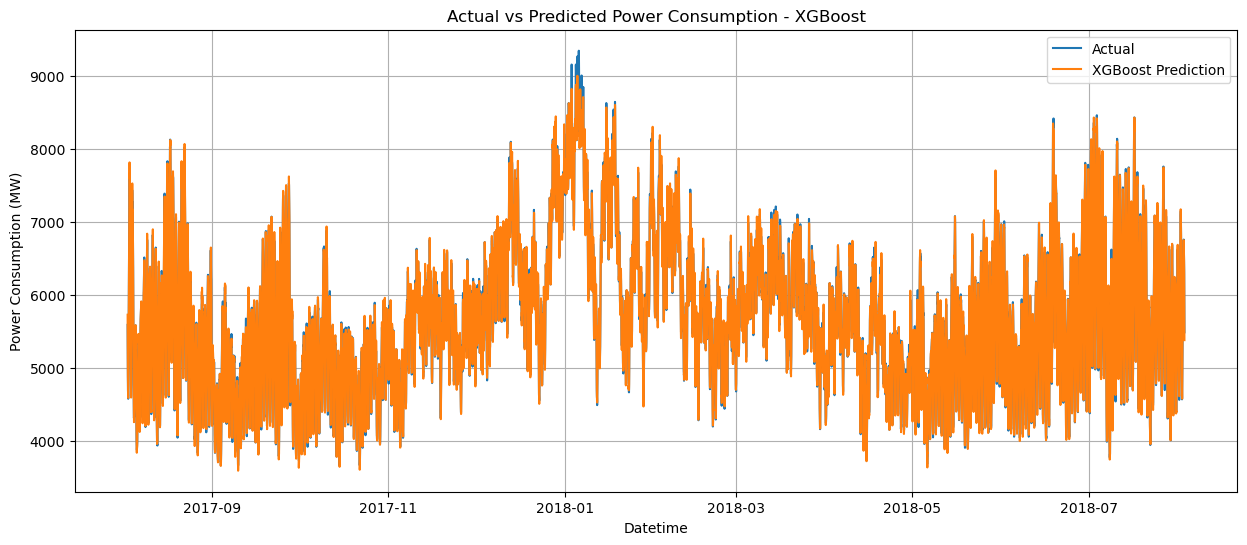

In [86]:
# ==========================================
# ACTUAL VS PREDICTED - BEST MODEL
# ==========================================

prediction_dict = {
    'Naive Baseline': naive_pred,
    'ARIMA': arima_pred,
    'SARIMA': sarima_pred,
    'Random Forest': rf_pred,
    'XGBoost': xgb_pred
}

best_model_name = best_model['Model']

best_prediction = prediction_dict[best_model_name]

plt.figure(figsize=(15, 6))

plt.plot(
    y_test.index,
    y_test.values,
    label='Actual'
)

plt.plot(
    best_prediction.index,
    best_prediction.values,
    label=f'{best_model_name} Prediction'
)

plt.title(
    f'Actual vs Predicted Power Consumption - {best_model_name}'
)

plt.xlabel('Datetime')
plt.ylabel('Power Consumption (MW)')

plt.legend()
plt.grid(True)

plt.show()

## Compare all model predictions

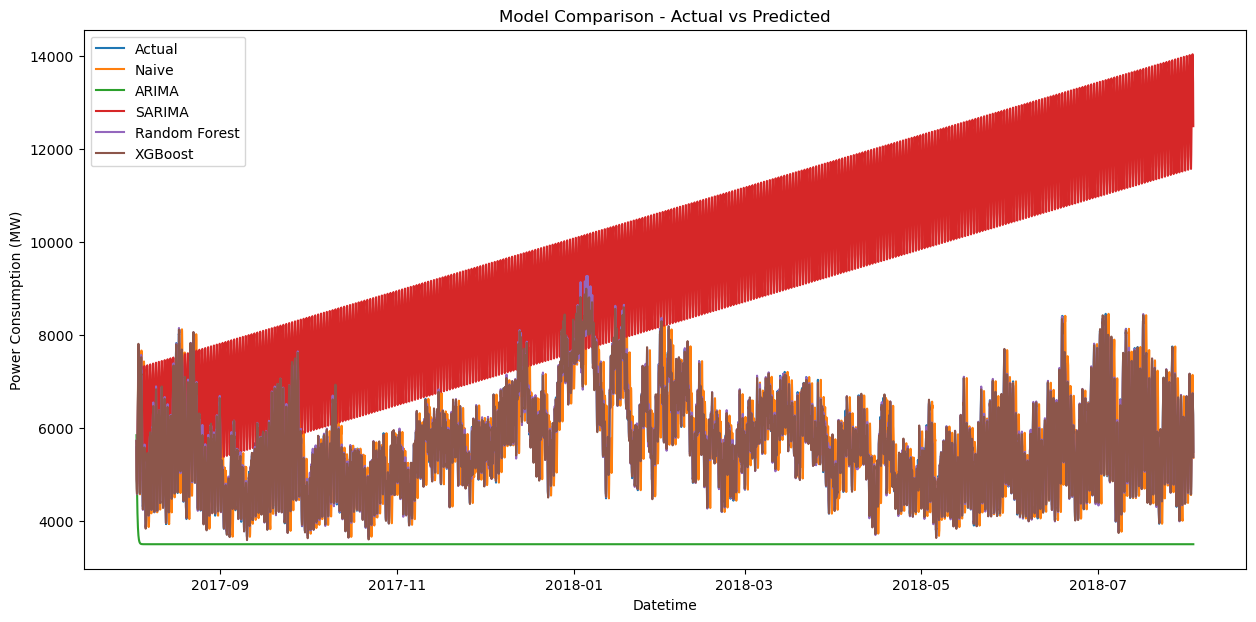

In [87]:
plt.figure(figsize=(15, 7))

plt.plot(
    y_test.index,
    y_test.values,
    label='Actual'
)

plt.plot(
    y_test.index,
    naive_pred.values,
    label='Naive'
)

plt.plot(
    y_test.index,
    arima_pred.values,
    label='ARIMA'
)

plt.plot(
    y_test.index,
    sarima_pred.values,
    label='SARIMA'
)

plt.plot(
    rf_pred.index,
    rf_pred.values,
    label='Random Forest'
)

plt.plot(
    xgb_pred.index,
    xgb_pred.values,
    label='XGBoost'
)

plt.title('Model Comparison - Actual vs Predicted')
plt.xlabel('Datetime')
plt.ylabel('Power Consumption (MW)')
plt.legend()

plt.show()

## XGBoost 


### Step-1 Feature Importance

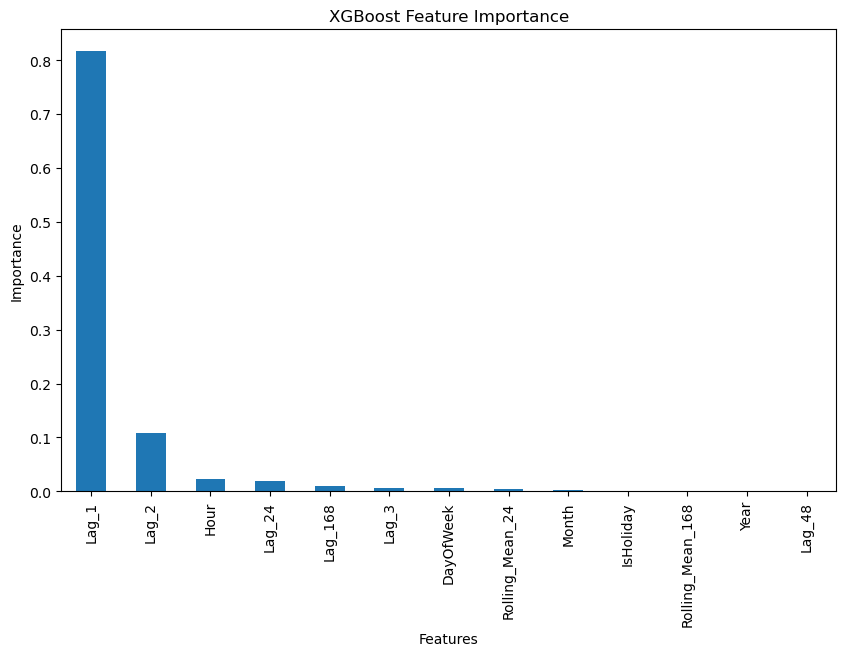

In [88]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=features
).sort_values(
    ascending=False
)

plt.figure(figsize=(10, 6))

importance.plot(kind='bar')

plt.title('XGBoost Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance')

plt.show()

### NEXT 30 DAYS ENERGY CONSUMPTION FORECAST

#### Step 2)Final XGBOOST MODEL

In [89]:
final_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

final_xgb.fit(
    ml_df[features],
    ml_df['PJMW_MW']
)

print("Final XGBoost model trained.")

Final XGBoost model trained.


### Step 3-Next 30 days Dates

In [90]:
last_timestamp = ml_df.index.max()

future_index = pd.date_range(
    start=last_timestamp + pd.Timedelta(hours=1),
    periods=24 * 30,
    freq='h'
)

print("Forecast starts:", future_index[0])
print("Forecast ends  :", future_index[-1])
print("Total hours    :", len(future_index))

Forecast starts: 2018-08-03 01:00:00
Forecast ends  : 2018-09-02 00:00:00
Total hours    : 720


### STEP 4 — Future Calendar Features

In [91]:
future_df = pd.DataFrame(index=future_index)

future_df['Hour'] = future_df.index.hour
future_df['DayOfWeek'] = future_df.index.dayofweek
future_df['Month'] = future_df.index.month
future_df['Year'] = future_df.index.year

future_df['IsHoliday'] = (
    future_df.index.normalize()
    .isin(holidays)
    .astype(int)
)

print(future_df.head())

                     Hour  DayOfWeek  Month  Year  IsHoliday
2018-08-03 01:00:00     1          4      8  2018          0
2018-08-03 02:00:00     2          4      8  2018          0
2018-08-03 03:00:00     3          4      8  2018          0
2018-08-03 04:00:00     4          4      8  2018          0
2018-08-03 05:00:00     5          4      8  2018          0


In [92]:
from pandas.tseries.holiday import USFederalHolidayCalendar

calendar = USFederalHolidayCalendar()

holidays = calendar.holidays(
    start=df.index.min(),
    end=df.index.max()
)                    

### Step 5-Main 30 days forecast

In [93]:
history = ml_df['PJMW_MW'].copy()

predictions = []

for timestamp in future_index:

    row = {}

    row['Hour'] = timestamp.hour
    row['DayOfWeek'] = timestamp.dayofweek
    row['Month'] = timestamp.month
    row['Year'] = timestamp.year

    row['IsHoliday'] = int(
        timestamp.normalize() in holidays
    )

    row['Lag_1'] = history.iloc[-1]
    row['Lag_2'] = history.iloc[-2]
    row['Lag_3'] = history.iloc[-3]

    row['Lag_24'] = history.iloc[-24]
    row['Lag_48'] = history.iloc[-48]
    row['Lag_168'] = history.iloc[-168]

    row['Rolling_Mean_24'] = (
        history.iloc[-24:].mean()
    )

    row['Rolling_Mean_168'] = (
        history.iloc[-168:].mean()
    )

    X_future = pd.DataFrame(
        [row],
        index=[timestamp]
    )[features]

    prediction = final_xgb.predict(X_future)[0]

    predictions.append(prediction)

    history.loc[timestamp] = prediction

print("30-day forecasting completed.")

30-day forecasting completed.


### STEP 6 — Forecast DataFrame

In [94]:
forecast_df = pd.DataFrame(
    {
        'Datetime': future_index,
        'Predicted_MW': predictions
    }
)

forecast_df = forecast_df.set_index('Datetime')

forecast_df.head()

,Predicted_MW
Datetime,
2018-08-03 01:00:00,5075.061523
2018-08-03 02:00:00,4797.692383
2018-08-03 03:00:00,4628.133301
2018-08-03 04:00:00,4542.821777
2018-08-03 05:00:00,4558.041992


### Step 7-Hourly Forecast Graph

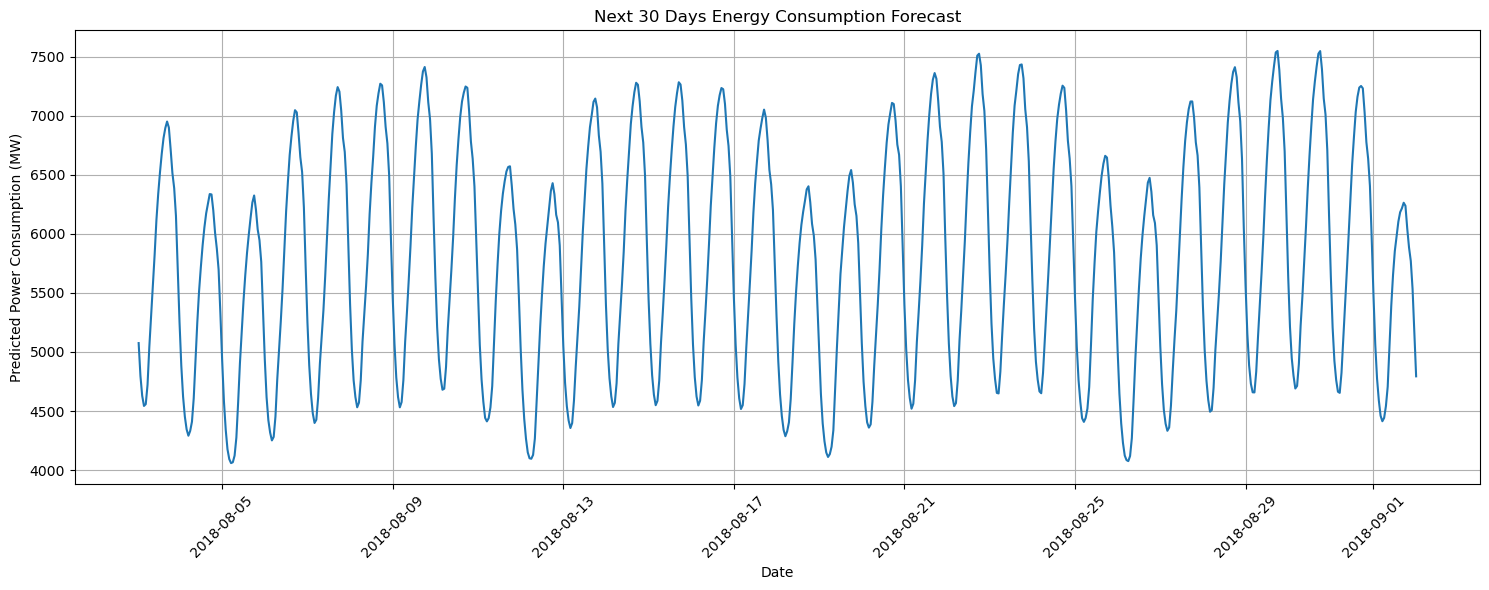

In [95]:
plt.figure(figsize=(15, 6))

plt.plot(
    forecast_df.index,
    forecast_df['Predicted_MW']
)

plt.title(
    'Next 30 Days Energy Consumption Forecast'
)

plt.xlabel('Date')
plt.ylabel('Predicted Power Consumption (MW)')

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Step-8 Daily Average forecast

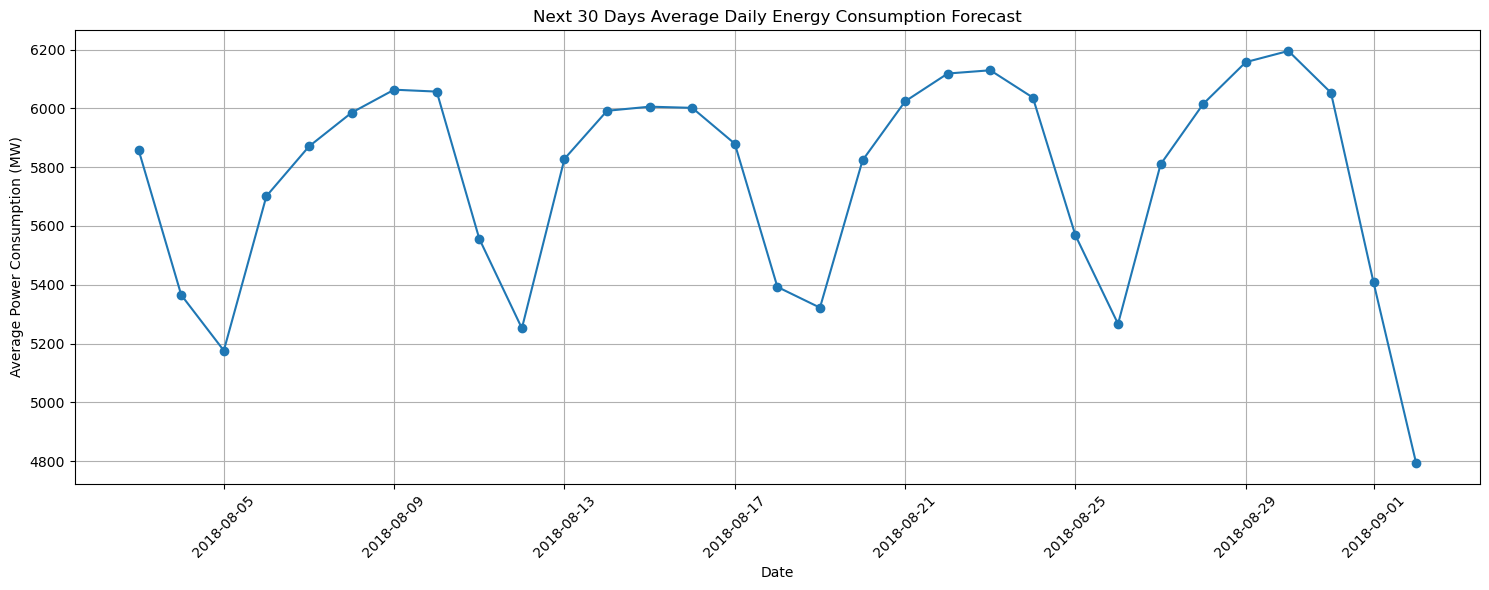

In [96]:
daily_forecast = (
    forecast_df['Predicted_MW']
    .resample('D')
    .mean()
)

plt.figure(figsize=(15, 6))

plt.plot(
    daily_forecast.index,
    daily_forecast.values,
    marker='o'
)

plt.title(
    'Next 30 Days Average Daily Energy Consumption Forecast'
)

plt.xlabel('Date')
plt.ylabel('Average Power Consumption (MW)')

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Step 9-CSV FILE

In [97]:
forecast_df.to_csv(
    'next_30_days_energy_forecast.csv'
)

print(
    "Forecast saved as next_30_days_energy_forecast.csv"
)

Forecast saved as next_30_days_energy_forecast.csv


In [98]:
import joblib

# Save the final XGBoost model
joblib.dump(final_xgb, 'xgboost_power_forecasting.pkl')

print("Final XGBoost model saved successfully!")

Final XGBoost model saved successfully!


In [99]:
import os

print(os.path.exists('xgboost_power_forecasting.pkl'))

True
